# LightGBM Binary Classifier — All Four Strategies
Strategies: **Unweighted | Weighted | SMOTE | Undersampling**

Helper functions are imported from `classifier_helper.py` (must be in the same directory).

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from skopt.space import Real, Integer, Categorical

from classifier_helper_v2 import (
    model_development_classifier,
    plot_classifier_performance,
    plot_cv_confusion_matrix,
    print_cv_metrics,
    evaluate_test_set,
    save_results,
    plot_comparison
)

## 0. Data Loading

In [2]:
df_binary = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_train  = df_binary[df_binary['Type'] == 'Train'].reset_index(drop=True)
df_test   = df_binary[df_binary['Type'] == 'Test'].reset_index(drop=True)

label        = 'MP_label'
output       = 'Binary'
model_name   = 'LGB'
num_trials   = 20
non_features = ['SMILES', 'MP', 'Type', label, output]

print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Class distribution (train):\n{df_train[output].value_counts()}")

Train: (12054, 88) | Test: (5166, 88)
Class distribution (train):
Binary
0    11439
1      615
Name: count, dtype: int64


---
## 1. Unweighted Classifier
Baseline — no imbalance correction. `scale_pos_weight` excluded from search space.

In [3]:
model_type = "classifier_unweighted"

search_space_unweighted = {
    'num_leaves':        Integer(20, 300),
    'max_depth':         Integer(3, 12),
    'learning_rate':     Real(0.01, 0.3, prior='log-uniform'),
    'n_estimators':      Integer(20, 500),
    'min_child_samples': Integer(10, 50),
    'subsample':         Real(0.6, 1.0),
    'colsample_bytree':  Real(0.4, 1.0),
    'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
    # scale_pos_weight excluded — no imbalance correction
}

results_unweighted, model_unweighted = model_development_classifier(
    data=df_train, non_feature_cols=non_features, target_col=output,
    trials=num_trials, search_space=search_space_unweighted, use_pipeline=False
)

save_results(results_unweighted, model_unweighted, model_name, model_type)

Trial  0 (default) | mean F1: 0.9468 ± 0.0044
Trial  1 | mean F1: 0.9475 ± 0.0037
Trial  2 | mean F1: 0.9480 ± 0.0039
Trial  3 | mean F1: 0.9467 ± 0.0044
Trial  4 | mean F1: 0.9461 ± 0.0039
Trial  5 | mean F1: 0.9475 ± 0.0024
Trial  6 | mean F1: 0.9474 ± 0.0038
Trial  7 | mean F1: 0.9464 ± 0.0036
Trial  8 | mean F1: 0.9467 ± 0.0033
Trial  9 | mean F1: 0.9467 ± 0.0037
Trial 10 | mean F1: 0.9480 ± 0.0046
Trial 11 | mean F1: 0.9452 ± 0.0043
Trial 12 | mean F1: 0.9241 ± 0.0006
Trial 13 | mean F1: 0.9386 ± 0.0033
Trial 14 | mean F1: 0.9374 ± 0.0040
Trial 15 | mean F1: 0.9455 ± 0.0042
Trial 16 | mean F1: 0.9241 ± 0.0006
Trial 17 | mean F1: 0.9475 ± 0.0034
Trial 18 | mean F1: 0.9452 ± 0.0048
Trial 19 | mean F1: 0.9473 ± 0.0035
Trial 20 | mean F1: 0.9466 ± 0.0040
Successfully saved trial results to model_development_results_LGB_classifier_unweighted.pkl
Successfully saved best model to best_model_LGB_classifier_unweighted.joblib


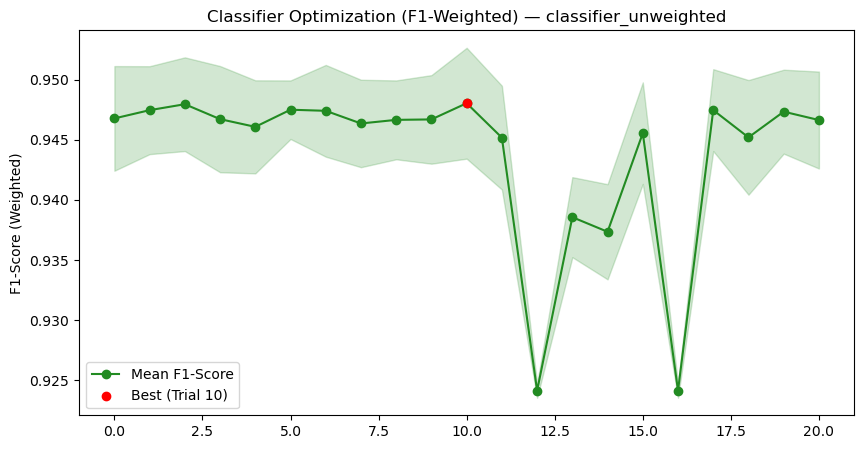

In [4]:
plot_classifier_performance(results_unweighted, model_type)

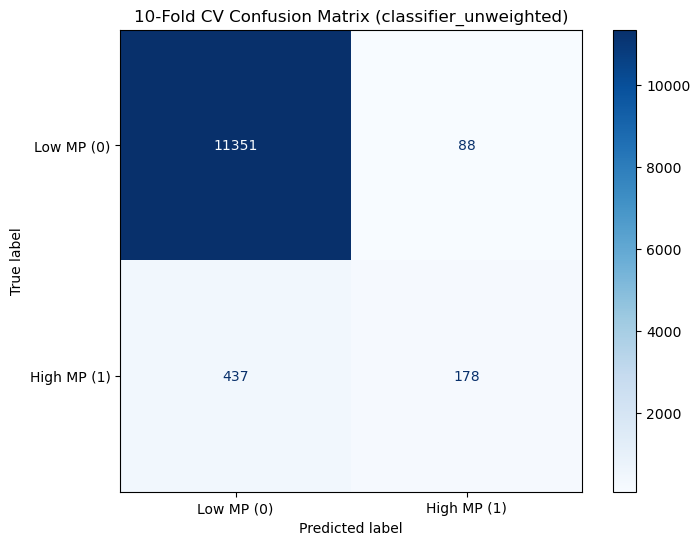

In [5]:
# Reload model (run this cell independently if kernel was restarted)
model_name   = 'LGB'
model_type   = 'classifier_unweighted'
label        = 'MP_label'
output       = 'Binary'
non_features = ['SMILES', 'MP', 'Type', label, output]
model_unweighted = joblib.load(f"best_model_{model_name}_{model_type}.joblib")

X_train = df_train.drop(columns=non_features)
y_train = df_train[output]
skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds   = list(skf.split(X_train, y_train))

y_pred_cv_unweighted, y_prob_cv_unweighted = plot_cv_confusion_matrix(
    model_unweighted, X_train, y_train, model_type, cv=folds)

In [6]:
print_cv_metrics(y_train, y_pred_cv_unweighted, y_prob_cv_unweighted, model_type)

--- Performance Metrics: classifier_unweighted Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9629     0.9923     0.9774      11439
     High MP     0.6692     0.2894     0.4041        615

    accuracy                           0.9564      12054
   macro avg     0.8161     0.6409     0.6907      12054
weighted avg     0.9479     0.9564     0.9481      12054

AUC-ROC: 0.9270


--- Final Test Results: classifier_unweighted Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9639     0.9898     0.9767       4903
     High MP     0.6183     0.3080     0.4112        263

    accuracy                           0.9551       5166
   macro avg     0.7911     0.6489     0.6939       5166
weighted avg     0.9463     0.9551     0.9479       5166

AUC-ROC: 0.9324


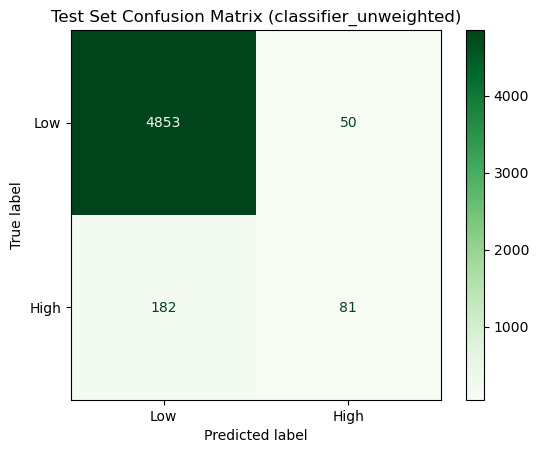

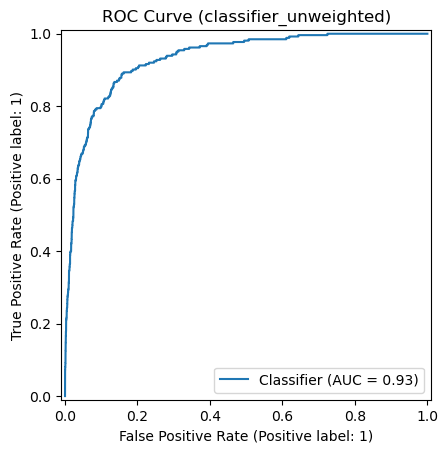

In [7]:
evaluate_test_set(model_unweighted, df_test, non_features, output, model_type)

---
## 2. Weighted Classifier
`scale_pos_weight` included as a tunable hyperparameter (range 1.0–5.0) for imbalance correction.

In [8]:
model_type = "classifier_weighted"

search_space_weighted = {
    'num_leaves':        Integer(20, 300),
    'max_depth':         Integer(3, 12),
    'learning_rate':     Real(0.01, 0.3, prior='log-uniform'),
    'n_estimators':      Integer(20, 500),
    'min_child_samples': Integer(10, 50),
    'subsample':         Real(0.6, 1.0),
    'colsample_bytree':  Real(0.4, 1.0),
    'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
    'scale_pos_weight':  Real(1.0, 5.0),  # Tunable class weight for imbalance correction
}

results_weighted, model_weighted = model_development_classifier(
    data=df_train, non_feature_cols=non_features, target_col=output,
    trials=num_trials, search_space=search_space_weighted, use_pipeline=False
)

save_results(results_weighted, model_weighted, model_name, model_type)

Trial  0 (default) | mean F1: 0.9468 ± 0.0044
Trial  1 | mean F1: 0.9480 ± 0.0037
Trial  2 | mean F1: 0.9487 ± 0.0031
Trial  3 | mean F1: 0.9496 ± 0.0042
Trial  4 | mean F1: 0.9521 ± 0.0038
Trial  5 | mean F1: 0.9494 ± 0.0035
Trial  6 | mean F1: 0.9481 ± 0.0037
Trial  7 | mean F1: 0.9484 ± 0.0033
Trial  8 | mean F1: 0.9499 ± 0.0038
Trial  9 | mean F1: 0.9493 ± 0.0026
Trial 10 | mean F1: 0.9481 ± 0.0029
Trial 11 | mean F1: 0.9241 ± 0.0006
Trial 12 | mean F1: 0.9403 ± 0.0036
Trial 13 | mean F1: 0.9379 ± 0.0036
Trial 14 | mean F1: 0.9241 ± 0.0006
Trial 15 | mean F1: 0.9426 ± 0.0038
Trial 16 | mean F1: 0.9505 ± 0.0041
Trial 17 | mean F1: 0.9480 ± 0.0035
Trial 18 | mean F1: 0.9514 ± 0.0038
Trial 19 | mean F1: 0.9452 ± 0.0037
Trial 20 | mean F1: 0.9474 ± 0.0042
Successfully saved trial results to model_development_results_LGB_classifier_weighted.pkl
Successfully saved best model to best_model_LGB_classifier_weighted.joblib


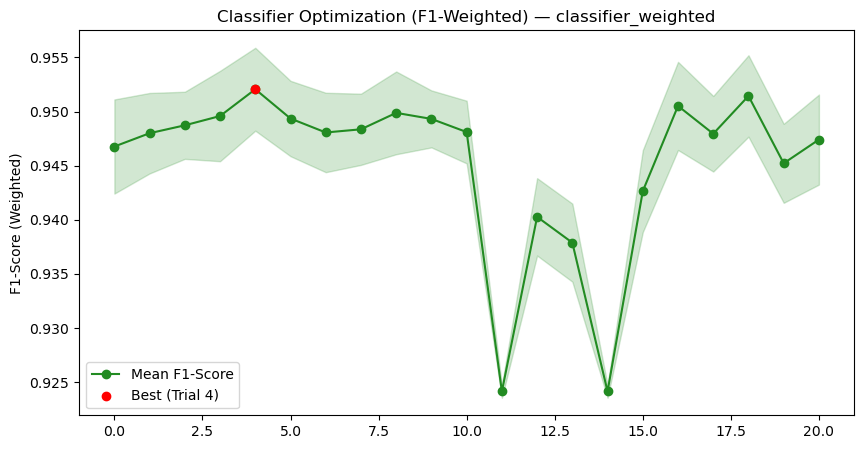

In [9]:
plot_classifier_performance(results_weighted, model_type)

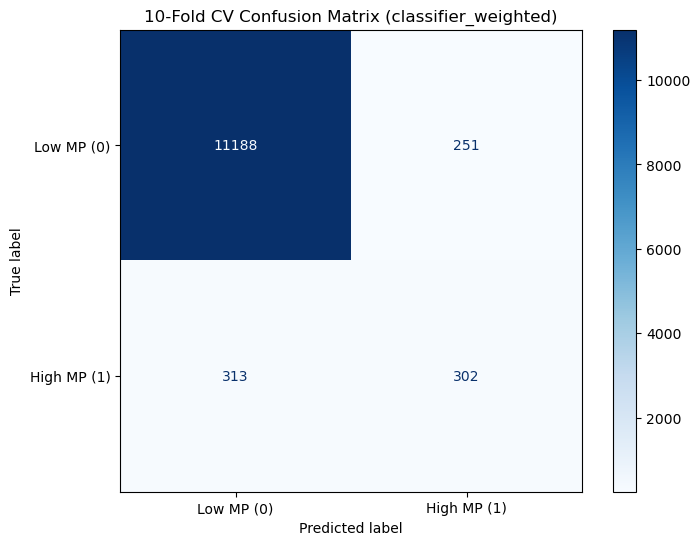

In [10]:
# Reload model (run this cell independently if kernel was restarted)
model_name   = 'LGB'
model_type   = 'classifier_weighted'
label        = 'MP_label'
output       = 'Binary'
non_features = ['SMILES', 'MP', 'Type', label, output]
model_weighted = joblib.load(f"best_model_{model_name}_{model_type}.joblib")

X_train = df_train.drop(columns=non_features)
y_train = df_train[output]
skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds   = list(skf.split(X_train, y_train))

y_pred_cv_weighted, y_prob_cv_weighted = plot_cv_confusion_matrix(
    model_weighted, X_train, y_train, model_type, cv=folds)

In [11]:
print_cv_metrics(y_train, y_pred_cv_weighted, y_prob_cv_weighted, model_type)

--- Performance Metrics: classifier_weighted Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9728     0.9781     0.9754      11439
     High MP     0.5461     0.4911     0.5171        615

    accuracy                           0.9532      12054
   macro avg     0.7594     0.7346     0.7463      12054
weighted avg     0.9510     0.9532     0.9520      12054

AUC-ROC: 0.9319


--- Final Test Results: classifier_weighted Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9737     0.9747     0.9742       4903
     High MP     0.5194     0.5095     0.5144        263

    accuracy                           0.9510       5166
   macro avg     0.7465     0.7421     0.7443       5166
weighted avg     0.9506     0.9510     0.9508       5166

AUC-ROC: 0.9265


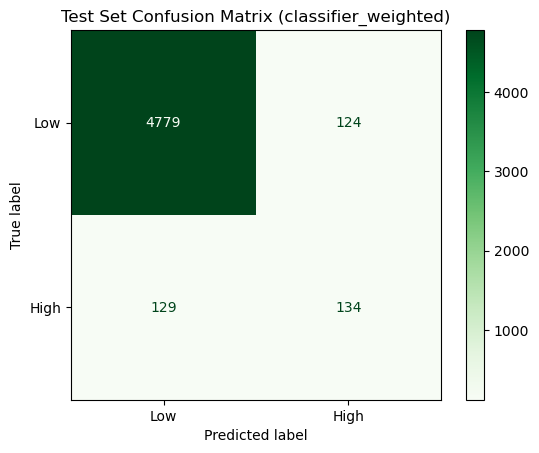

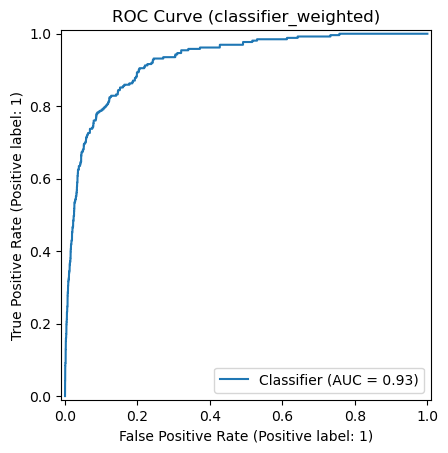

In [12]:
evaluate_test_set(model_weighted, df_test, non_features, output, model_type)

---
## 3. SMOTE (Oversampling)
SMOTE applied only inside each CV fold via ImbPipeline. `scale_pos_weight` locked at 1.0.

In [13]:
model_type = "classifier_SMOTE"

# 'classification__' prefix targets the LGBM step inside the pipeline
search_space_smote = {
    'classification__num_leaves':        Integer(20, 300),
    'classification__max_depth':         Integer(3, 12),
    'classification__learning_rate':     Real(0.01, 0.3, prior='log-uniform'),
    'classification__n_estimators':      Integer(20, 500),
    'classification__min_child_samples': Integer(10, 50),
    'classification__subsample':         Real(0.6, 1.0),
    'classification__colsample_bytree':  Real(0.4, 1.0),
    'classification__reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'classification__reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
    'classification__scale_pos_weight':  Categorical([1.0]),  # Locked — SMOTE handles imbalance
}

results_smote, model_smote = model_development_classifier(
    data=df_train, non_feature_cols=non_features, target_col=output,
    trials=num_trials, search_space=search_space_smote,
    use_pipeline=True, pipeline_type='smote'
)

save_results(results_smote, model_smote, model_name, model_type)

Trial  0 (default) | mean F1: 0.9493 ± 0.0040
Trial  1 | mean F1: 0.9482 ± 0.0052
Trial  2 | mean F1: 0.9493 ± 0.0034
Trial  3 | mean F1: 0.9461 ± 0.0031
Trial  4 | mean F1: 0.9465 ± 0.0045
Trial  5 | mean F1: 0.9488 ± 0.0043
Trial  6 | mean F1: 0.9479 ± 0.0037
Trial  7 | mean F1: 0.9484 ± 0.0037
Trial  8 | mean F1: 0.9493 ± 0.0042
Trial  9 | mean F1: 0.9478 ± 0.0038
Trial 10 | mean F1: 0.9472 ± 0.0043
Trial 11 | mean F1: 0.9256 ± 0.0043
Trial 12 | mean F1: 0.9263 ± 0.0050
Trial 13 | mean F1: 0.9487 ± 0.0043
Trial 14 | mean F1: 0.9423 ± 0.0043
Trial 15 | mean F1: 0.9455 ± 0.0043
Trial 16 | mean F1: 0.9427 ± 0.0046
Trial 17 | mean F1: 0.9181 ± 0.0047
Trial 18 | mean F1: 0.9132 ± 0.0051
Trial 19 | mean F1: 0.9480 ± 0.0041
Trial 20 | mean F1: 0.9006 ± 0.0047
Successfully saved trial results to model_development_results_LGB_classifier_SMOTE.pkl
Successfully saved best model to best_model_LGB_classifier_SMOTE.joblib


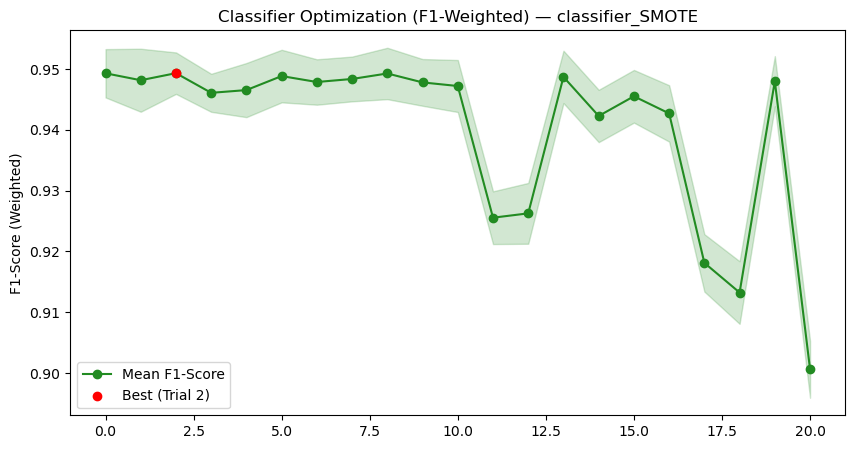

In [14]:
plot_classifier_performance(results_smote, model_type)

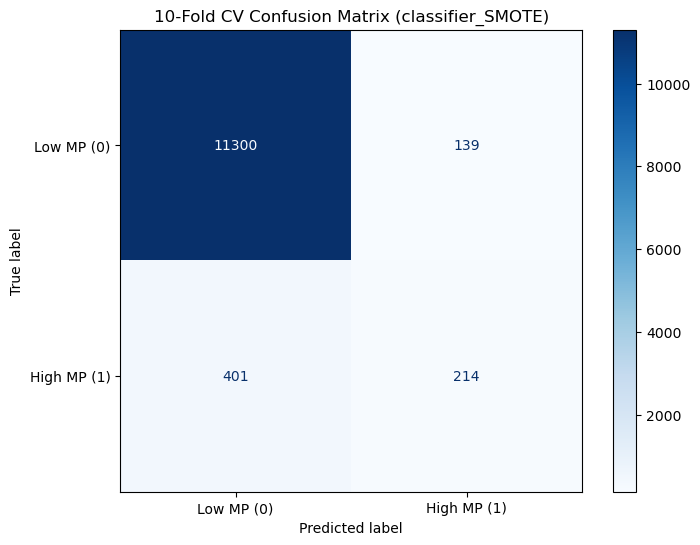

In [15]:
# Reload model (run this cell independently if kernel was restarted)
model_name   = 'LGB'
model_type   = 'classifier_SMOTE'
label        = 'MP_label'
output       = 'Binary'
non_features = ['SMILES', 'MP', 'Type', label, output]
model_smote  = joblib.load(f"best_model_{model_name}_{model_type}.joblib")

X_train = df_train.drop(columns=non_features)
y_train = df_train[output]
skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds   = list(skf.split(X_train, y_train))

y_pred_cv_smote, y_prob_cv_smote = plot_cv_confusion_matrix(
    model_smote, X_train, y_train, model_type, cv=folds)

In [16]:
print_cv_metrics(y_train, y_pred_cv_smote, y_prob_cv_smote, model_type)

--- Performance Metrics: classifier_SMOTE Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9657     0.9878     0.9767      11439
     High MP     0.6062     0.3480     0.4421        615

    accuracy                           0.9552      12054
   macro avg     0.7860     0.6679     0.7094      12054
weighted avg     0.9474     0.9552     0.9494      12054

AUC-ROC: 0.9225


--- Final Test Results: classifier_SMOTE Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9674     0.9855     0.9764       4903
     High MP     0.5848     0.3802     0.4608        263

    accuracy                           0.9547       5166
   macro avg     0.7761     0.6829     0.7186       5166
weighted avg     0.9479     0.9547     0.9501       5166

AUC-ROC: 0.9286


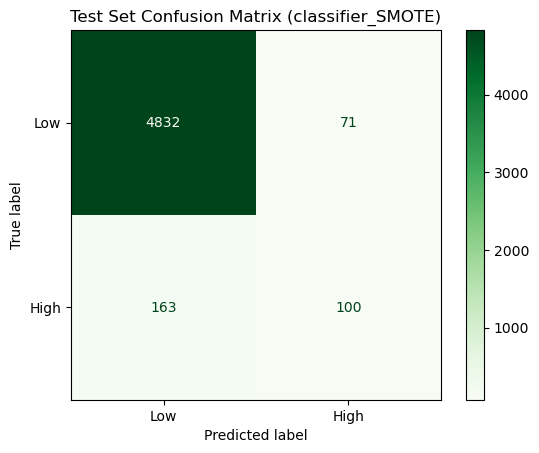

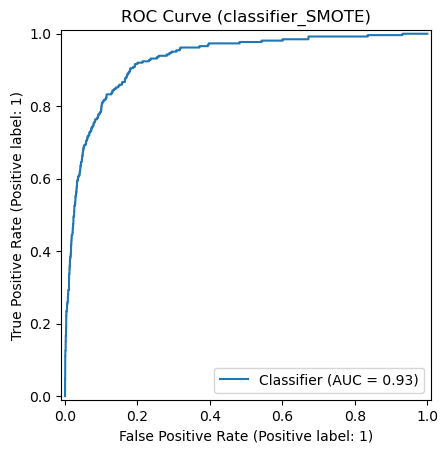

In [17]:
evaluate_test_set(model_smote, df_test, non_features, output, model_type)

---
## 4. Undersampling (ENN + RandomUnderSampler)
Two-step pipeline: ENN for boundary cleaning, RandomUnderSampler for balancing.
Applied only inside each CV fold via ImbPipeline. `scale_pos_weight` locked at 1.0.

In [18]:
model_type = "classifier_undersampling"

# 'classification__' prefix targets the LGBM step inside the pipeline
search_space_under = {
    'classification__num_leaves':        Integer(20, 300),
    'classification__max_depth':         Integer(3, 12),
    'classification__learning_rate':     Real(0.01, 0.3, prior='log-uniform'),
    'classification__n_estimators':      Integer(20, 500),
    'classification__min_child_samples': Integer(10, 50),
    'classification__subsample':         Real(0.6, 1.0),
    'classification__colsample_bytree':  Real(0.4, 1.0),
    'classification__reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'classification__reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
    'classification__scale_pos_weight':  Categorical([1.0]),  # Locked — undersampling handles imbalance
}

results_under, model_under = model_development_classifier(
    data=df_train, non_feature_cols=non_features, target_col=output,
    trials=num_trials, search_space=search_space_under,
    use_pipeline=True, pipeline_type='undersampling'
)

save_results(results_under, model_under, model_name, model_type)

Trial  0 (default) | mean F1: 0.8621 ± 0.0065
Trial  1 | mean F1: 0.8602 ± 0.0048
Trial  2 | mean F1: 0.8589 ± 0.0060
Trial  3 | mean F1: 0.8558 ± 0.0037
Trial  4 | mean F1: 0.8525 ± 0.0075
Trial  5 | mean F1: 0.8588 ± 0.0059
Trial  6 | mean F1: 0.8583 ± 0.0045
Trial  7 | mean F1: 0.8586 ± 0.0040
Trial  8 | mean F1: 0.8608 ± 0.0054
Trial  9 | mean F1: 0.8609 ± 0.0064
Trial 10 | mean F1: 0.8611 ± 0.0061
Trial 11 | mean F1: 0.8600 ± 0.0057
Trial 12 | mean F1: 0.8587 ± 0.0069
Trial 13 | mean F1: 0.8563 ± 0.0079
Trial 14 | mean F1: 0.8610 ± 0.0050
Trial 15 | mean F1: 0.8516 ± 0.0079
Trial 16 | mean F1: 0.8480 ± 0.0063
Trial 17 | mean F1: 0.8385 ± 0.0085
Trial 18 | mean F1: 0.8579 ± 0.0062
Trial 19 | mean F1: 0.8534 ± 0.0057
Trial 20 | mean F1: 0.8487 ± 0.0085
Successfully saved trial results to model_development_results_LGB_classifier_undersampling.pkl
Successfully saved best model to best_model_LGB_classifier_undersampling.joblib


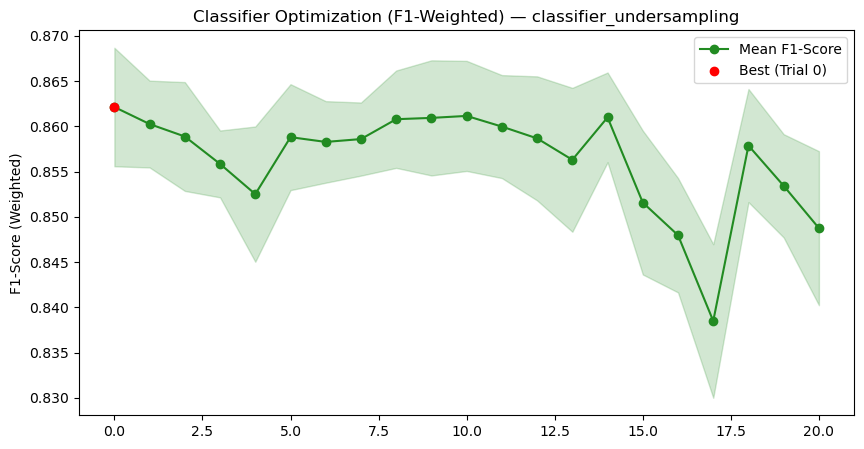

In [19]:
plot_classifier_performance(results_under, model_type)

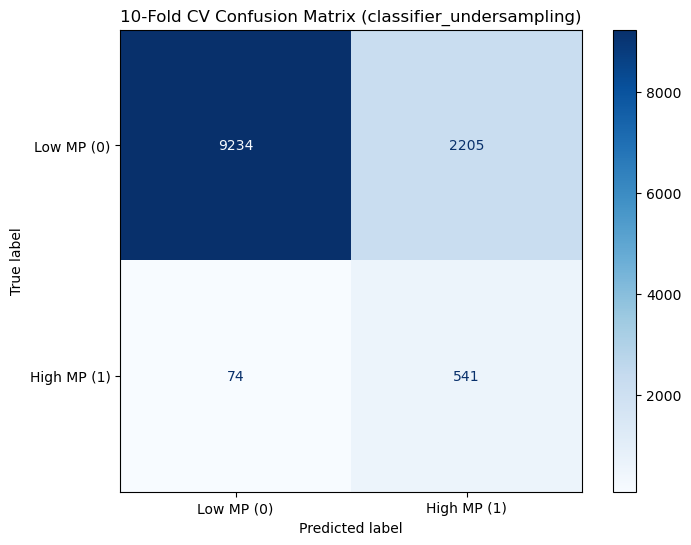

In [20]:
# Reload model (run this cell independently if kernel was restarted)
model_name   = 'LGB'
model_type   = 'classifier_undersampling'
label        = 'MP_label'
output       = 'Binary'
non_features = ['SMILES', 'MP', 'Type', label, output]
model_under  = joblib.load(f"best_model_{model_name}_{model_type}.joblib")

X_train = df_train.drop(columns=non_features)
y_train = df_train[output]
skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
folds   = list(skf.split(X_train, y_train))

y_pred_cv_under, y_prob_cv_under = plot_cv_confusion_matrix(
    model_under, X_train, y_train, model_type, cv=folds)

In [21]:
print_cv_metrics(y_train, y_pred_cv_under, y_prob_cv_under, model_type)

--- Performance Metrics: classifier_undersampling Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9920     0.8072     0.8902      11439
     High MP     0.1970     0.8797     0.3219        615

    accuracy                           0.8109      12054
   macro avg     0.5945     0.8435     0.6060      12054
weighted avg     0.9515     0.8109     0.8612      12054

AUC-ROC: 0.9191


--- Final Test Results: classifier_undersampling Strategy ---
              precision     recall   f1-score    support

      Low MP     0.9920     0.8336     0.9059       4903
     High MP     0.2199     0.8745     0.3514        263

    accuracy                           0.8357       5166
   macro avg     0.6059     0.8540     0.6287       5166
weighted avg     0.9527     0.8357     0.8777       5166

AUC-ROC: 0.9254


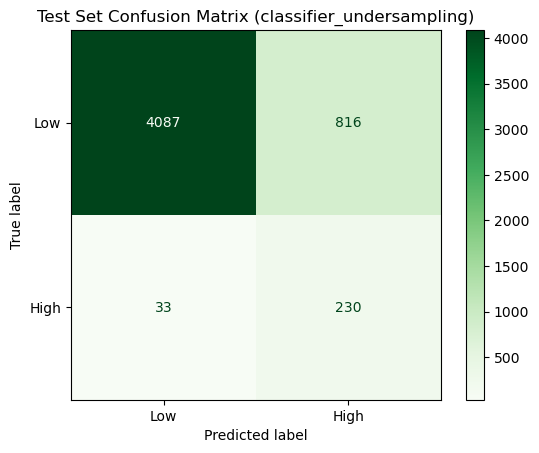

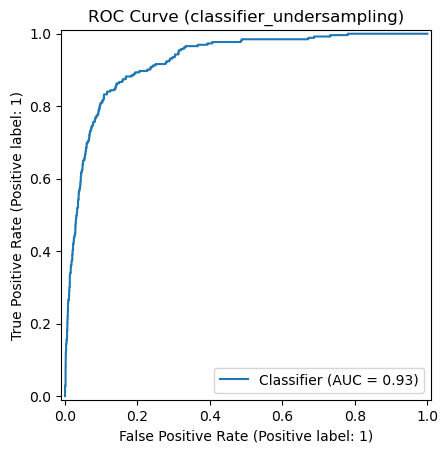

In [22]:
evaluate_test_set(model_under, df_test, non_features, output, model_type)

---
## 5. Strategy Comparison
Replace placeholder values with your actual results before running.

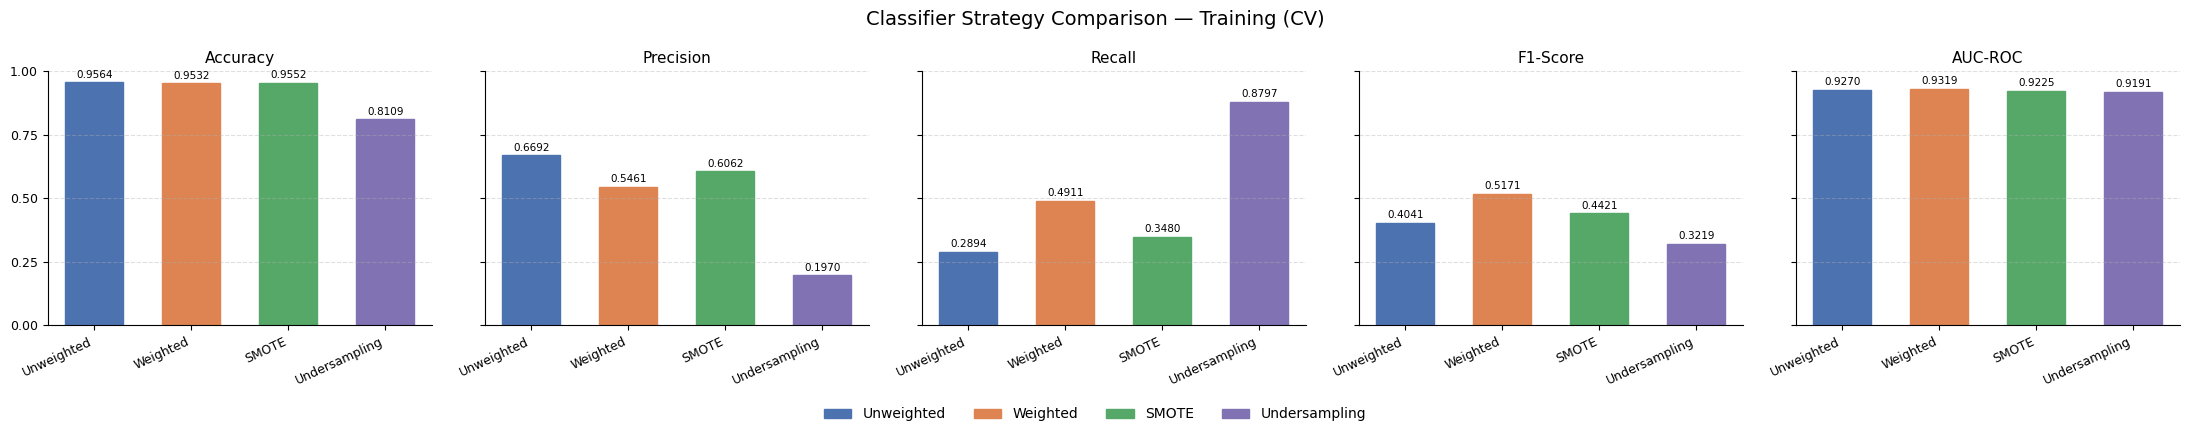

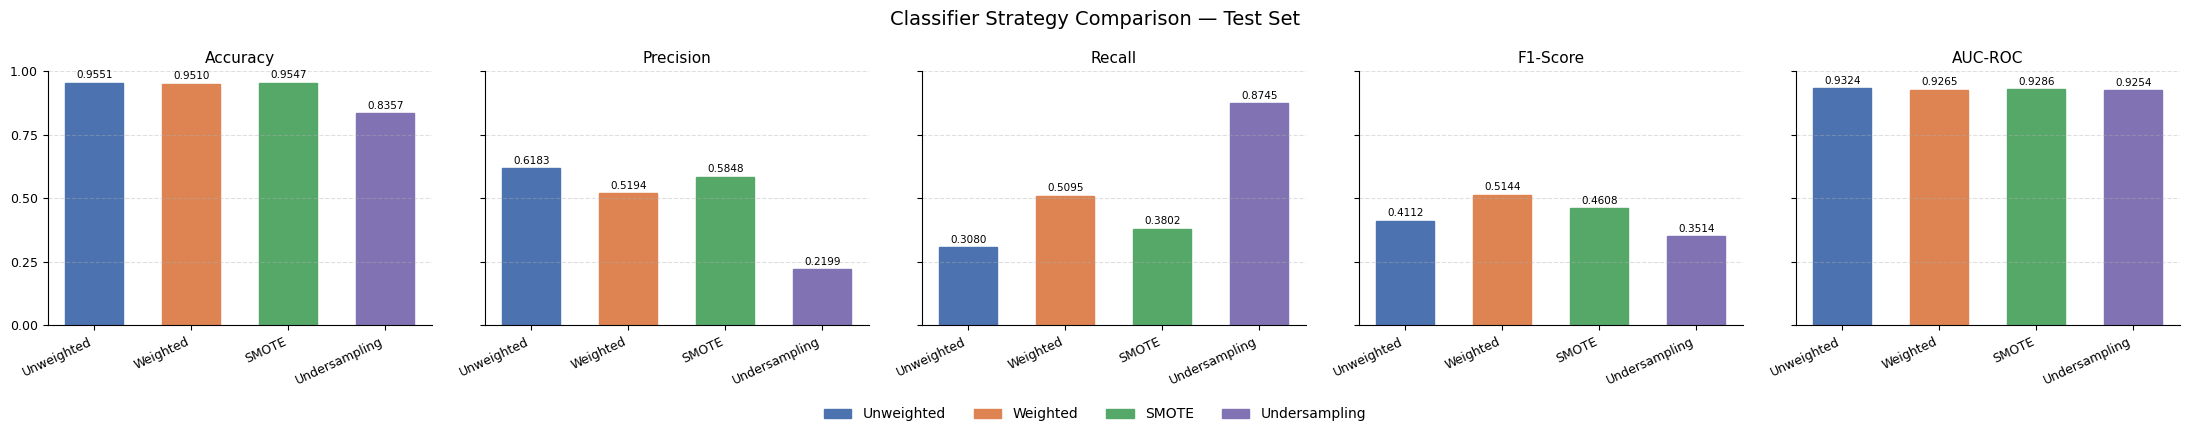

In [4]:
color_scheme = {
    'L':      '#4c72b0',
    'H':      '#dd8452',
    'All':    '#55a868',
    'Purple': '#8172b3',
    'Red':    '#e74c3c',
    'Extra':  '#4d4d4d'
}

strategies = ['Unweighted', 'Weighted', 'SMOTE', 'Undersampling']

train_results = {
    'Accuracy':  [0.9564, 0.9532, 0.9552, 0.8109],
    'Precision': [0.6692, 0.5461, 0.6062, 0.1970],
    'Recall':    [0.2894, 0.4911, 0.3480, 0.8797],
    'F1-Score':  [0.4041, 0.5171, 0.4421, 0.3219],
    'AUC-ROC':   [0.9270, 0.9319, 0.9225, 0.9191]
}

test_results = {
    'Accuracy':  [0.9551, 0.9510, 0.9547, 0.8357],
    'Precision': [0.6183, 0.5194, 0.5848, 0.2199],
    'Recall':    [0.3080, 0.5095, 0.3802, 0.8745],
    'F1-Score':  [0.4112, 0.5144, 0.4608, 0.3514],
    'AUC-ROC':   [0.9324, 0.9265, 0.9286, 0.9254]
}
plot_comparison(train_results, test_results, strategies, color_scheme)